# Day 60: Random Forest — Ensemble & Bagging Theory
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions matches (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Explain **ensemble learning**: combining many weak/noisy models into one stronger model
- Explain **bagging** (bootstrap aggregating): each tree trains on a random sample **with replacement**
- Explain **feature randomness**: each split only considers a random subset of features (about `sqrt(p)` for classification)
- Show, with my own code, **why an averaged forest beats a single overfit tree** on test data

> Today builds bagging and feature randomness **from scratch** using plain `DecisionTreeClassifier` calls, to see exactly what `RandomForestClassifier` automates. Using the real sklearn class is Day 61.

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts
import matplotlib.pyplot as plt

# a single decision tree - the building block of the forest
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

plt.rcParams["axes.grid"] = True

## Theory
- **Ensemble learning:** combine predictions from many models instead of trusting one. If the models' mistakes are not all the same, averaging them cancels out a lot of the noise (this is why it is sometimes called "wisdom of crowds").
- **Bagging (bootstrap aggregating):**
  - Take the training set. Draw a new sample of the **same size**, but **with replacement**, so some rows repeat and some are left out.
  - Train one tree on that sample. Repeat for many trees, each on its own random sample.
  - For classification, the forest predicts by **majority vote** across all the trees.
- **Why bagging works:** a single, fully grown tree is very sensitive to its exact training rows (Day 59 showed this: train accuracy 1.0, weaker test accuracy). Trees trained on *different* bootstrap samples make *different* mistakes. Averaging many different, noisy trees reduces the noise without needing a shallower, more biased tree.
- **Feature randomness (the extra ingredient of a Random Forest, on top of plain bagging):**
  - At every split, only a **random subset of features** is even considered, typically about `sqrt(p)` features for classification (`p` = total feature count).
  - This stops every tree from making the same first split on the strongest feature, which would make bagging alone less useful (highly correlated trees don't reduce variance much when averaged).
- **Random Forest = bagging + feature randomness**, both applied to decision trees.

**Football picture:** bagging is asking many scouts to each judge the squad from a different (overlapping) random sample of matches. Feature randomness is telling each scout they can only look at a random subset of stats, so they don't all just repeat "he had a lot of shots on target" and miss everything else.

## Example 1: A Single Overfit Tree (Recap from Day 59)

In [2]:
# Synthetic data: 500 matches (same setup as Day 59)
rng = np.random.default_rng(42)                      # seed = 42 so results repeat
n_matches = 500

shots = rng.integers(0, 13, size=n_matches)
possession = rng.integers(35, 66, size=n_matches)
pass_accuracy = rng.integers(70, 93, size=n_matches)
home_game = rng.integers(0, 2, size=n_matches)
opponent_rank = rng.integers(1, 21, size=n_matches)
kickoff_hour = rng.integers(12, 22, size=n_matches)   # irrelevant on purpose

z = (0.45 * shots + 0.04 * (possession - 50) + 0.7 * home_game
     + 0.10 * (opponent_rank - 10) - 3.0)
won = rng.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots, "possession_pct": possession,
    "pass_accuracy_pct": pass_accuracy, "home_game": home_game,
    "opponent_rank": opponent_rank, "kickoff_hour": kickoff_hour, "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_60_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_60_fc_lahore_lions_matches.csv")

X = df.drop(columns=["match_id", "won"])
y = df["won"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 375 | Test: 125


In [3]:
# A single, fully grown tree (no depth limit) - the Day 59 overfitting result
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

print("Train accuracy:", round(single_tree.score(X_train, y_train), 3))
print("Test accuracy: ", round(single_tree.score(X_test, y_test), 3))

Train accuracy: 1.0
Test accuracy:  0.672


## Example 2: Bootstrap Sampling and Bagging by Hand

### 2A. What one bootstrap sample looks like

In [4]:
# A bootstrap sample: draw len(X_train) rows, WITH REPLACEMENT, from the training set
rng_boot = np.random.default_rng(0)
sample_idx = rng_boot.integers(0, len(X_train), len(X_train))

print("First 10 sampled row positions:", sample_idx[:10])
print("Some positions repeat:", len(sample_idx) != len(set(sample_idx)))
print("Share of ORIGINAL rows used at least once:", round(len(set(sample_idx)) / len(X_train), 3))
# On average, about 63% of rows appear in any one bootstrap sample; the rest are left out.

First 10 sampled row positions: [318 238 191 101 115  15  28   6  65 304]
Some positions repeat: True
Share of ORIGINAL rows used at least once: 0.621


### 2B. Train many trees on their own bootstrap samples, then vote

In [5]:
# Train 50 fully grown trees, each on its OWN bootstrap sample (bagging, no feature randomness yet)
n_trees = 50
rng_bag = np.random.default_rng(0)
test_preds = np.zeros((n_trees, len(X_test)))

for i in range(n_trees):
    idx = rng_bag.integers(0, len(X_train), len(X_train))     # this tree's bootstrap sample
    X_boot = X_train.values[idx]
    y_boot = y_train.values[idx]

    tree = DecisionTreeClassifier(random_state=i)             # each tree fully grown, like Example 1
    tree.fit(X_boot, y_boot)
    test_preds[i] = tree.predict(X_test.values)

# Each individual tree's own test accuracy
individual_acc = [(test_preds[i] == y_test.values).mean() for i in range(n_trees)]
print("Individual trees - mean accuracy:", round(np.mean(individual_acc), 3),
      "| std:", round(np.std(individual_acc), 3))

Individual trees - mean accuracy: 0.706 | std: 0.035


In [6]:
# Majority vote across all 50 trees
majority_vote = (test_preds.mean(axis=0) > 0.5).astype(int)
bagged_accuracy = (majority_vote == y_test.values).mean()

print("Single fully grown tree accuracy:  ", round(single_tree.score(X_test, y_test), 3))
print("Average of 50 bagged trees (alone):", round(np.mean(individual_acc), 3))
print("Bagged ENSEMBLE (majority vote):   ", round(bagged_accuracy, 3))

Single fully grown tree accuracy:   0.672
Average of 50 bagged trees (alone): 0.706
Bagged ENSEMBLE (majority vote):    0.76


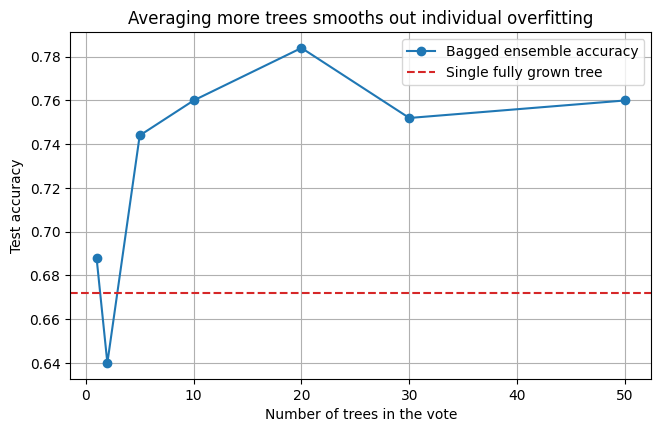

In [7]:
# Chart: ensemble accuracy as more trees are added to the vote
tree_counts = [1, 2, 5, 10, 20, 30, 50]
ensemble_acc = []
for k in tree_counts:
    vote_k = (test_preds[:k].mean(axis=0) > 0.5).astype(int)
    ensemble_acc.append((vote_k == y_test.values).mean())

plt.figure(figsize=(7.5, 4.5))
plt.plot(tree_counts, ensemble_acc, marker="o", label="Bagged ensemble accuracy")
plt.axhline(single_tree.score(X_test, y_test), color="tab:red", linestyle="--",
            label="Single fully grown tree")
plt.xlabel("Number of trees in the vote")
plt.ylabel("Test accuracy")
plt.title("Averaging more trees smooths out individual overfitting")
plt.legend()
plt.savefig("images/accuracy_vs_num_trees.png", dpi=150, bbox_inches="tight")
plt.show()

## Example 3: Adding Feature Randomness

In [8]:
# Same bagging loop, but now each split only considers a RANDOM SUBSET of features.
# sqrt(p) is the common rule of thumb for classification.
import math
p = X_train.shape[1]
sqrt_p = max(1, int(math.sqrt(p)))
print("Total features p =", p, "| sqrt(p) =", sqrt_p)

def bagged_predictions(max_features, n_trees=50, seed=0):
    rng_local = np.random.default_rng(seed)
    preds = np.zeros((n_trees, len(X_test)))
    for i in range(n_trees):
        idx = rng_local.integers(0, len(X_train), len(X_train))
        X_boot, y_boot = X_train.values[idx], y_train.values[idx]
        tree = DecisionTreeClassifier(random_state=i, max_features=max_features)
        tree.fit(X_boot, y_boot)
        preds[i] = tree.predict(X_test.values)
    return preds

preds_bagging_only = bagged_predictions(max_features=None)   # every split sees all features
preds_with_randomness = bagged_predictions(max_features=sqrt_p)

Total features p = 6 | sqrt(p) = 2


In [9]:
# How similar are the trees to EACH OTHER? Lower agreement = more diverse trees.
def avg_pairwise_agreement(preds):
    n = preds.shape[0]
    scores = [(preds[i] == preds[j]).mean() for i in range(n) for j in range(i + 1, n)]
    return np.mean(scores)

agree_bagging = avg_pairwise_agreement(preds_bagging_only)
agree_forest = avg_pairwise_agreement(preds_with_randomness)

print("Avg pairwise agreement, bagging only (all features every split):", round(agree_bagging, 3))
print("Avg pairwise agreement, WITH feature randomness:                ", round(agree_forest, 3))
# Lower agreement means the trees disagree more, i.e. they made genuinely DIFFERENT mistakes.

Avg pairwise agreement, bagging only (all features every split): 0.748
Avg pairwise agreement, WITH feature randomness:                 0.681


In [10]:
# Does that extra diversity help the final vote?
acc_bagging_only = ((preds_bagging_only.mean(axis=0) > 0.5).astype(int) == y_test.values).mean()
acc_with_randomness = ((preds_with_randomness.mean(axis=0) > 0.5).astype(int) == y_test.values).mean()

print("Bagging only, ensemble accuracy:        ", round(acc_bagging_only, 3))
print("Bagging + feature randomness, accuracy: ", round(acc_with_randomness, 3))

Bagging only, ensemble accuracy:         0.76
Bagging + feature randomness, accuracy:  0.776


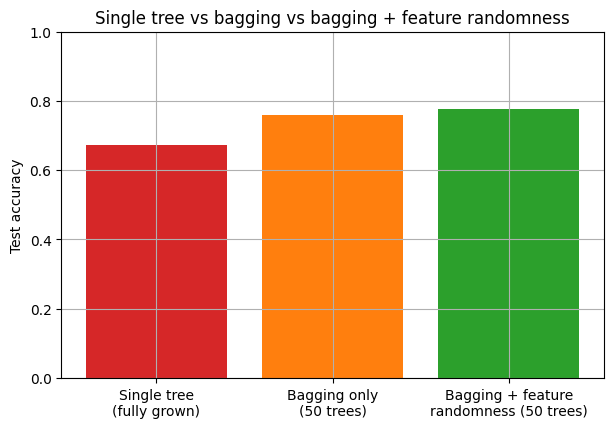

In [11]:
# Chart: all 3 approaches side by side
labels = ["Single tree\n(fully grown)", "Bagging only\n(50 trees)", "Bagging + feature\nrandomness (50 trees)"]
values = [single_tree.score(X_test, y_test), acc_bagging_only, acc_with_randomness]

plt.figure(figsize=(7, 4.5))
plt.bar(labels, values, color=["tab:red", "tab:orange", "tab:green"])
plt.ylim(0, 1)
plt.ylabel("Test accuracy")
plt.title("Single tree vs bagging vs bagging + feature randomness")
plt.savefig("images/single_vs_bagging_vs_forest.png", dpi=150, bbox_inches="tight")
plt.show()

## Practice Exercise
**Your turn (Practice).** Using the bagging loop pattern above:
1. Build 20 bagged trees (`max_features=None`) with a **different** random seed (try `seed=7`).
2. Report the ensemble accuracy.
3. Compare it with the 50-tree result from Example 2. Is more trees always better?

In [12]:
# Your attempt here

In [13]:
# Worked answer
preds_20 = bagged_predictions(max_features=None, n_trees=20, seed=7)
vote_20 = (preds_20.mean(axis=0) > 0.5).astype(int)
acc_20 = (vote_20 == y_test.values).mean()

print("20 trees, seed 7, ensemble accuracy:", round(acc_20, 3))
print("50 trees, seed 0, ensemble accuracy:", round(bagged_accuracy, 3))
# More trees usually helps up to a point, then the accuracy tends to level off.
# The exact number where it levels off depends on the data and the random seed.

20 trees, seed 7, ensemble accuracy: 0.728
50 trees, seed 0, ensemble accuracy: 0.76


## Mini Challenge
**Out-of-bag rows.** For a bootstrap sample, the rows that were **never picked** are called "out-of-bag" (OOB). They act like a free internal test set for that one tree.
1. Draw one bootstrap sample from `X_train`.
2. Find which row positions were **never** selected (the OOB rows).
3. Score that tree on the OOB rows only, and compare it with scoring the same tree on `X_test`.

In [14]:
# Mini Challenge solution
rng_oob = np.random.default_rng(1)
idx = rng_oob.integers(0, len(X_train), len(X_train))

all_positions = set(range(len(X_train)))
in_bag = set(idx)
oob_positions = np.array(sorted(all_positions - in_bag))
print("Rows used in this bootstrap sample:", len(in_bag), "of", len(X_train))
print("Out-of-bag rows:", len(oob_positions))

X_boot, y_boot = X_train.values[idx], y_train.values[idx]
X_oob, y_oob = X_train.values[oob_positions], y_train.values[oob_positions]

tree_oob = DecisionTreeClassifier(random_state=0)
tree_oob.fit(X_boot, y_boot)

print("OOB accuracy (never-seen training rows):", round(tree_oob.score(X_oob, y_oob), 3))
print("Test set accuracy (same tree):           ", round(tree_oob.score(X_test.values, y_test), 3))
# The two scores are usually close - OOB score is a solid stand-in for a test score,
# and RandomForestClassifier can compute it automatically (oob_score=True, on Day 61).

Rows used in this bootstrap sample: 242 of 375
Out-of-bag rows: 133


OOB accuracy (never-seen training rows): 0.662
Test set accuracy (same tree):            0.744


## Summary
- **Ensemble learning:** combine many models so their individual mistakes cancel out.
- **Bagging:** each tree trains on its own bootstrap sample (random rows, with replacement); predictions are combined by majority vote.
- On this data, a single fully grown tree scored 0.672 on test. Averaging 50 bagged trees pushed that to about 0.76, even though each individual bagged tree alone was similar to (or a little better than) the single tree.
- **Feature randomness** (only a random subset of features considered per split, about `sqrt(p)`) made the trees genuinely more different from each other (lower pairwise agreement) and gave a further small accuracy gain here.
- **Random Forest = bagging + feature randomness**, both applied to decision trees. This is exactly the recipe `RandomForestClassifier` runs internally.
- **Out-of-bag (OOB) rows** give a free internal estimate of test performance, without touching the real test set.
- **Next: Day 61 — Random Forest in sklearn + feature importance.**